# 02 -- Training (dua fase, resume-safe)

Melatih satu backbone ConvNeXt per run notebook ini (ganti `BACKBONE` di
sel konfigurasi, jalankan lagi untuk backbone lain -- BUKAN 4 notebook
terpisah seperti eksperimen lama, supaya tidak ada copy-paste bug lagi).

**Prasyarat (wajib sebelum jalan):**
1. `results/split_manifest.json` sudah ada (dari `01_dataset_audit.ipynb`
   + resplit -- gerbang audit GAGAL 34.84% kebocoran, split lama dari
   Kaggle TIDAK dipakai lagi).
2. Dataset ada di `/content/drive/MyDrive/Bone_Fracture_Dataset` (struktur
   sama seperti lokal -- manifest pakai path RELATIF, jadi portable).
3. Repo `project-fracture` accessible dari Colab (public di GitHub) --
   sel berikutnya clone otomatis.

**Resume:** kalau sesi Colab terputus, jalankan ulang notebook ini dari
atas dengan `BACKBONE` yang sama -- `src/fracture/train.py` baca
`status.json` di `runs/<run_id>/` dan lanjut dari epoch terakhir yang
benar-benar tersimpan, TIDAK mengulang dari ImageNet weights.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Konfigurasi -- SATU-SATUNYA baris yang perlu diganti per run

In [2]:
BACKBONE = "base"  # ganti ke "tiny" / "small" / "base" / "large"

DATASET_ROOT = "/content/drive/MyDrive/project-fracture/dataset/Bone_Fracture_Dataset"  # sesuai path nyata di Drive-mu (dari run 01_dataset_audit.ipynb) -- GANTI kalau strukturmu beda
REPO_URL = "https://github.com/alianhar/project-fracture.git"
REPO_DIR = "/content/project-fracture"
RUNS_ROOT = "/content/drive/MyDrive/fracture-runs"  # di Drive -- selamat dari disconnect

In [3]:
import os
import shutil

def _is_valid_git_repo(path):
    return os.path.isdir(os.path.join(path, ".git"))

# Bersihkan sisa clone gagal dari percobaan sebelumnya (folder ada tapi
# bukan git repo valid) -- tanpa ini, run berikutnya masuk ke `git pull`
# di folder yang bukan repo dan gagal dengan error baru yang membingungkan.
if os.path.exists(REPO_DIR) and not _is_valid_git_repo(REPO_DIR):
    print(f"{REPO_DIR} ada tapi bukan git repo valid (sisa percobaan gagal) -- dihapus, clone ulang.")
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

# Gagal di sini secara EKSPLISIT kalau clone/pull tidak sukses -- supaya
# error jelas muncul di cell ini, bukan menyamar jadi ModuleNotFoundError
# yang membingungkan beberapa cell kemudian.
assert _is_valid_git_repo(REPO_DIR), (
    f"Clone/pull gagal -- {REPO_DIR} bukan git repo valid. "
    "Cek repo GitHub public & REPO_URL benar (lihat output !git di atas)."
)

import sys
sys.path.insert(0, REPO_DIR)

Cloning into '/content/project-fracture'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 185 (delta 7), reused 173 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (185/185), 2.24 MiB | 22.09 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [4]:
!pip -q install pyyaml

In [5]:
import json
import hashlib
from pathlib import Path

import yaml
import tensorflow as tf

from src.fracture.data import make_generators, compute_class_weight
from src.fracture.train import run_training

# Config terkunci + override backbone (spec Sec6.1) -- HANYA backbone yang
# beda antar model, seluruh hyperparameter lain identik.
with open(f"{REPO_DIR}/configs/base.yaml") as f:
    config = yaml.safe_load(f)

override_file = "base_model.yaml" if BACKBONE == "base" else f"{BACKBONE}.yaml"
with open(f"{REPO_DIR}/configs/{override_file}") as f:
    config.update(yaml.safe_load(f))

print(json.dumps(config, indent=2))

{
  "seed": 42,
  "img_size": 224,
  "batch_size": 16,
  "preprocessing": "convnext_native",
  "augment_train": {
    "rotation_range": 15,
    "zoom_range": 0.15,
    "horizontal_flip": true
  },
  "split_manifest": "results/split_manifest.json",
  "use_class_weight": true,
  "phase1": {
    "epochs": 30,
    "lr": 0.0001,
    "frozen": true
  },
  "phase2": {
    "epochs": 40,
    "lr": 1e-05,
    "unfreeze_last_stages": 2
  },
  "callbacks": {
    "early_stopping": {
      "monitor": "val_loss",
      "patience": 8,
      "restore_best_weights": true
    },
    "reduce_lr": {
      "monitor": "val_loss",
      "patience": 4,
      "factor": 0.5
    },
    "checkpoint": {
      "save_best_only": true
    }
  },
  "backbone": "base"
}


In [6]:
tf.keras.utils.set_random_seed(config["seed"])  # fix R1: seed didefinisikan tapi tidak dipakai di eksperimen lama

# Hash config -- run_dir stabil untuk config yang sama (resume jalan lintas
# eksekusi notebook), tapi berubah otomatis kalau config diubah (jadi run
# baru, bukan tercampur dengan hasil config lama).
config_str = json.dumps(config, sort_keys=True)
config_hash = hashlib.sha256(config_str.encode()).hexdigest()[:8]
run_id = f"{BACKBONE}_{config_hash}"
run_dir = f"{RUNS_ROOT}/{run_id}"

print("run_id:", run_id)
print("run_dir:", run_dir)

run_id: base_cf7600d6
run_dir: /content/drive/MyDrive/fracture-runs/base_cf7600d6


## Salin dataset ke disk lokal Colab (sekali per sesi)

Baca file gambar langsung dari Drive tiap step training itu LAMBAT --
Drive itu network filesystem, bukan disk lokal (ini persis bottleneck
yang bikin epoch pertama Small di eksperimen lama makan 4116 detik,
spec catatan R6). Cuma 3.370 gambar KANONIK (hasil dedup) yang disalin
-- bukan seluruh 10.581 file mentah -- jadi lebih cepat dari copy penuh.

Sentinel file (`.copy_done`) mencegah nyalin ulang kalau cell ini
dijalankan lagi di sesi yang sama (mis. setelah resume).

In [7]:
import json as _json
import shutil
from pathlib import Path

LOCAL_DATASET_ROOT = "/content/dataset_local"
_sentinel = Path(LOCAL_DATASET_ROOT) / ".copy_done"

if not _sentinel.exists():
    with open(f"{REPO_DIR}/results/split_manifest.json") as f:
        _manifest = _json.load(f)

    n = len(_manifest["clusters"])
    print(f"Menyalin {n} gambar unik dari Drive ke disk lokal Colab (sekali saja per sesi)...")
    for i, c in enumerate(_manifest["clusters"]):
        src = Path(DATASET_ROOT) / c["canonical_path"]
        dst = Path(LOCAL_DATASET_ROOT) / c["canonical_path"]
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{n}")

    _sentinel.parent.mkdir(parents=True, exist_ok=True)
    _sentinel.touch()
    print("Selesai menyalin.")
else:
    print("Sudah pernah disalin di sesi ini -- lewati.")

Menyalin 3370 gambar unik dari Drive ke disk lokal Colab (sekali saja per sesi)...
  500/3370
  1000/3370
  1500/3370
  2000/3370
  2500/3370
  3000/3370
Selesai menyalin.


## Data -- dari split_manifest.json, BUKAN struktur folder Kaggle asli

In [8]:
manifest_path = f"{REPO_DIR}/results/split_manifest.json"

train_gen, val_gen, test_gen = make_generators(
    manifest_path=manifest_path,
    dataset_root=LOCAL_DATASET_ROOT,
    img_size=config["img_size"],
    batch_size=config["batch_size"],
    seed=config["seed"],
    augment_train=config["augment_train"],
)

class_weight = compute_class_weight(manifest_path, LOCAL_DATASET_ROOT) if config["use_class_weight"] else None
print("class_indices:", train_gen.class_indices)
print("class_weight:", class_weight)
print(f"train={train_gen.samples}  val={val_gen.samples}  test={test_gen.samples}")

Found 2358 validated image filenames belonging to 2 classes.
Found 504 validated image filenames belonging to 2 classes.
Found 508 validated image filenames belonging to 2 classes.
class_indices: {'fractured': 0, 'not_fractured': 1}
class_weight: {0: np.float64(1.1993896236012207), 1: np.float64(0.8574545454545455)}
train=2358  val=504  test=508


## Training -- resume otomatis kalau run_dir sudah punya checkpoint

In [9]:
best_model_path = run_training(
    backbone_name=BACKBONE,
    train_gen=train_gen,
    val_gen=val_gen,
    class_weight=class_weight,
    run_dir=run_dir,
    config=config,
)
print("Model terbaik tersimpan di:", best_model_path)

[base] Mulai dari ImageNet weights.
350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6341 - loss: 0.6406

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


148/148 ━━━━━━━━━━━━━━━━━━━━ 108s 540ms/step - accuracy: 0.6968 - loss: 0.5722 - val_accuracy: 0.7560 - val_loss: 0.5215 - learning_rate: 1.0000e-04
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 427ms/step - accuracy: 0.8104 - loss: 0.4416 - val_accuracy: 0.8056 - val_loss: 0.4400 - learning_rate: 1.0000e-04
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 356ms/step - accuracy: 0.8372 - loss: 0.4010 - val_accuracy: 0.7837 - val_loss: 0.4526 - learning_rate: 1.0000e-04
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 58s 391ms/step - accuracy: 0.8469 - loss: 0.3651 - val_accuracy: 0.7798 - val_loss: 0.4483 - learning_rate: 1.0000e-04
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 62s 418ms/step - accuracy: 0.8673 - loss: 0.3313 - val_accuracy: 0.8135 - val_loss: 0.3958 - learning_rate: 1.0000e-04
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 65s 441ms/step - accuracy: 0.8770 - loss: 0.3158 - val_accuracy: 0.8115 - val_loss: 0.3890 - learning_rate: 1.0000e-04
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 60s 402ms/step -

## Sanity check cepat di test set (evaluasi formal ada di 03_evaluate_export.ipynb)

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model = tf.keras.models.load_model(best_model_path)

y_prob = model.predict(test_gen, steps=len(test_gen), verbose=1).ravel()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy (threshold 0.5, sanity check saja):", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=sorted(train_gen.class_indices, key=train_gen.class_indices.get), digits=4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 692ms/step
Accuracy (threshold 0.5, sanity check saja): 0.9901574803149606

               precision    recall  f1-score   support

    fractured     0.9859    0.9906    0.9882       212
not_fractured     0.9932    0.9899    0.9915       296

     accuracy                         0.9902       508
    macro avg     0.9896    0.9902    0.9899       508
 weighted avg     0.9902    0.9902    0.9902       508



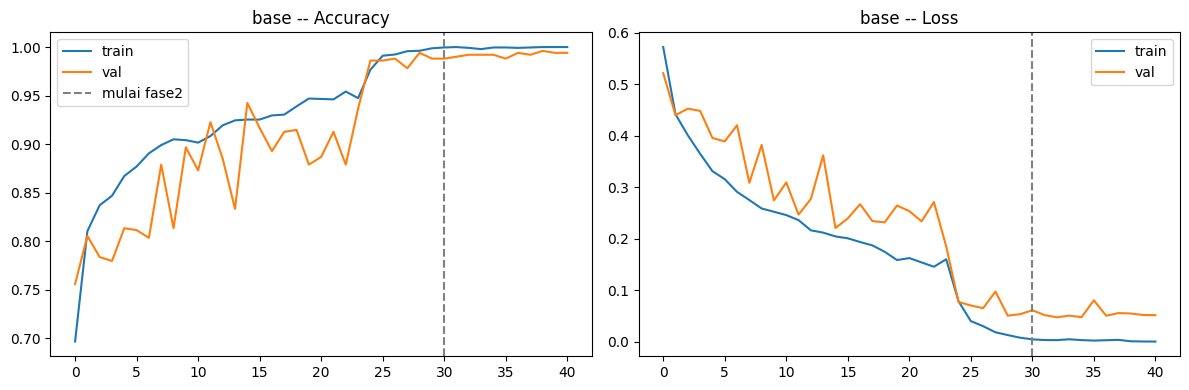

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

hist1 = pd.read_csv(f"{run_dir}/history_phase1.csv")
hist2 = pd.read_csv(f"{run_dir}/history_phase2.csv")
hist = pd.concat([hist1, hist2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="val")
axes[0].axvline(config["phase1"]["epochs"], color="gray", linestyle="--", label="mulai fase2")
axes[0].set_title(f"{BACKBONE} -- Accuracy")
axes[0].legend()

axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="val")
axes[1].axvline(config["phase1"]["epochs"], color="gray", linestyle="--")
axes[1].set_title(f"{BACKBONE} -- Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{run_dir}/training_curve.png", dpi=120)
plt.show()

---

## Lanjut ke backbone berikutnya

Sengaja ditaruh di SATU notebook yang sama (bukan file terpisah per
backbone) -- itu justru salah satu bug eksperimen lama yang diperbaiki
di project ini (4 notebook terpisah = rawan copy-paste bug beda-beda
antar model).

**Cara pakai:** ganti `BACKBONE` di sel bawah, jalankan 3 sel di section
ini (training -> sanity check -> plot). Ulangi untuk tiap backbone yang
tersisa (`tiny` -> `base` -> `large`).

**Prasyarat** (kalau kernel baru/fresh, bukan lanjutan sesi sebelumnya):
jalankan dulu cell Drive-mount, git-clone, dan salin-dataset-lokal di
paling atas notebook ini -- section ini TIDAK mengulang itu, sengaja
supaya tidak clone/copy ulang tiap ganti backbone (keduanya sudah
idempoten kalau dijalankan lagi, tapi tidak perlu). Kalau masih di sesi
kernel yang sama setelah training backbone sebelumnya, `train_gen` /
`val_gen` / `test_gen` / `class_weight` sudah ada di memori dan dipakai
ulang apa adanya -- keempat backbone pakai augmentasi & batch_size yang
identik (`configs/base.yaml`), cuma arsitekturnya yang beda, jadi
generator tidak perlu dibangun ulang tiap ganti model.

In [13]:
BACKBONE = "large"  # ganti ke "tiny" / "base" / "large" tiap mau latih backbone lain

with open(f"{REPO_DIR}/configs/base.yaml") as f:
    config = yaml.safe_load(f)

override_file = "base_model.yaml" if BACKBONE == "base" else f"{BACKBONE}.yaml"
with open(f"{REPO_DIR}/configs/{override_file}") as f:
    config.update(yaml.safe_load(f))

# FIX OOM: Turunkan batch_size untuk backbone Large agar muat di GPU Colab
if BACKBONE == "large":
    print("Backbone Large terdeteksi. Menurunkan batch_size ke 8 untuk mencegah OOM...")
    config["batch_size"] = 8

config_str = json.dumps(config, sort_keys=True)
config_hash = hashlib.sha256(config_str.encode()).hexdigest()[:8]
run_id = f"{BACKBONE}_{config_hash}"
run_dir = f"{RUNS_ROOT}/{run_id}"
print("run_id:", run_id)
print("run_dir:", run_dir)

# Membangun ulang generator karena batch_size berubah
train_gen, val_gen, test_gen = make_generators(
    manifest_path=manifest_path,
    dataset_root=LOCAL_DATASET_ROOT,
    img_size=config["img_size"],
    batch_size=config["batch_size"],
    seed=config["seed"],
    augment_train=config["augment_train"],
)

best_model_path = run_training(
    backbone_name=BACKBONE,
    train_gen=train_gen,
    val_gen=val_gen,
    class_weight=class_weight,
    run_dir=run_dir,
    config=config,
)
print("Model terbaik tersimpan di:", best_model_path)

Backbone Large terdeteksi. Menurunkan batch_size ke 8 untuk mencegah OOM...
run_id: large_789f2c2e
run_dir: /content/drive/MyDrive/fracture-runs/large_789f2c2e
Found 2358 validated image filenames belonging to 2 classes.
Found 504 validated image filenames belonging to 2 classes.
Found 508 validated image filenames belonging to 2 classes.
[large] Mulai dari ImageNet weights.
Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6714 - loss: 0.6107

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


295/295 ━━━━━━━━━━━━━━━━━━━━ 155s 431ms/step - accuracy: 0.7426 - loss: 0.5290 - val_accuracy: 0.8452 - val_loss: 0.3825 - learning_rate: 1.0000e-04
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 138s 468ms/step - accuracy: 0.8444 - loss: 0.3729 - val_accuracy: 0.8889 - val_loss: 0.3265 - learning_rate: 1.0000e-04
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 141s 479ms/step - accuracy: 0.8834 - loss: 0.2976 - val_accuracy: 0.9306 - val_loss: 0.2466 - learning_rate: 1.0000e-04
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 139s 470ms/step - accuracy: 0.8986 - loss: 0.2616 - val_accuracy: 0.9127 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 146s 494ms/step - accuracy: 0.9143 - loss: 0.2238 - val_accuracy: 0.9464 - val_loss: 0.1962 - learning_rate: 1.0000e-04
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 111s 377ms/step - accuracy: 0.9249 - loss: 0.1957 - val_accuracy: 0.9167 - val_loss: 0.2023 - learning_rate: 1.0000e-04
Epoch 7/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 110s 371ms/

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model = tf.keras.models.load_model(best_model_path)

y_prob = model.predict(test_gen, steps=len(test_gen), verbose=1).ravel()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

print(f"[{BACKBONE}] Accuracy (threshold 0.5, sanity check saja):", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=sorted(train_gen.class_indices, key=train_gen.class_indices.get), digits=4))

64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 395ms/step
[large] Accuracy (threshold 0.5, sanity check saja): 0.9940944881889764

               precision    recall  f1-score   support

    fractured     0.9953    0.9906    0.9929       212
not_fractured     0.9933    0.9966    0.9949       296

     accuracy                         0.9941       508
    macro avg     0.9943    0.9936    0.9939       508
 weighted avg     0.9941    0.9941    0.9941       508



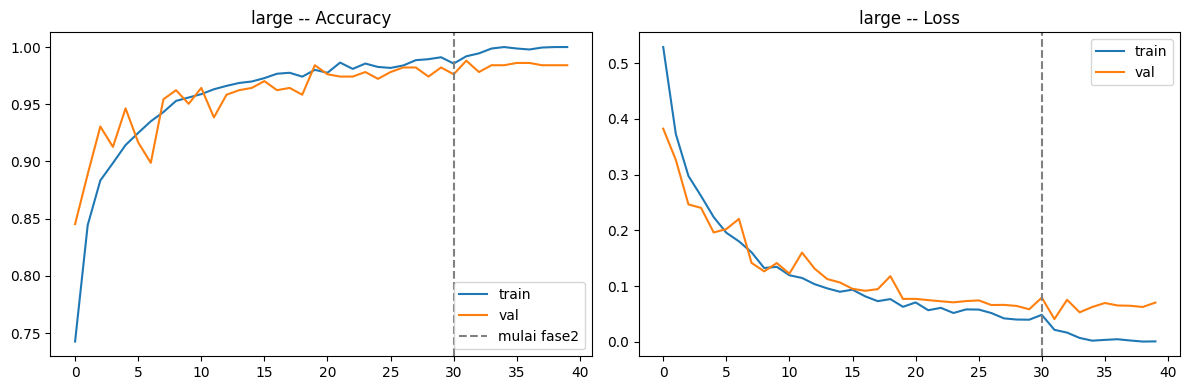

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

hist1 = pd.read_csv(f"{run_dir}/history_phase1.csv")
hist2 = pd.read_csv(f"{run_dir}/history_phase2.csv")
hist = pd.concat([hist1, hist2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="val")
axes[0].axvline(config["phase1"]["epochs"], color="gray", linestyle="--", label="mulai fase2")
axes[0].set_title(f"{BACKBONE} -- Accuracy")
axes[0].legend()

axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="val")
axes[1].axvline(config["phase1"]["epochs"], color="gray", linestyle="--")
axes[1].set_title(f"{BACKBONE} -- Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{run_dir}/training_curve.png", dpi=120)
plt.show()